<a href="https://colab.research.google.com/github/Zuhair0000/TensorFlow-ML-DL-Project-Practice/blob/main/NLP_level_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/Ankit152/IMDB-sentiment-analysis/master/IMDB-Dataset.csv')
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [3]:
df['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


In [4]:
X = df['review'].values
y = df['sentiment'].values

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ML

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

model = Pipeline([
    ('vecorizer', TfidfVectorizer(stop_words='english', max_features=5000)),
    ('model', MultinomialNB())
])

In [28]:
model.fit(X_train, y_train)

Pipeline(steps=[('vecorizer',
                 TfidfVectorizer(max_features=5000, stop_words='english')),
                ('model', MultinomialNB())])

In [29]:
y_pred = model.predict(X_test)
y_pred

array(['negative', 'positive', 'negative', ..., 'positive', 'negative',
       'negative'], dtype='<U8')

In [30]:
from sklearn.metrics import classification_report, confusion_matrix

print(f"Classification Report: \n{classification_report(y_test, y_pred)}")
print(f"Confusion Matrix: \n{confusion_matrix(y_test, y_pred)}")

Classification Report: 
              precision    recall  f1-score   support

    negative       0.85      0.85      0.85      4961
    positive       0.85      0.85      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000

Confusion Matrix: 
[[4209  752]
 [ 739 4300]]


# Deep Learning (TF)

In [6]:
import tensorflow as tf

vocab_size = 10000
sequence_length = 200

vectorize_layer = tf.keras.layers.TextVectorization(
    max_tokens=vocab_size,
    output_mode='int',
    output_sequence_length=sequence_length
)

In [7]:
vectorize_layer.adapt(X_train)

In [8]:
# Pass a raw string through our trained machine
sample_review = "This movie was absolutely terrible, I hated it."
print(vectorize_layer([sample_review]))

tf.Tensor(
[[  11   18   14  409  375   10 1727    9    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0  

In [13]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1, ), dtype=tf.string),

    vectorize_layer,

    tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=64, mask_zero=True),

    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.LSTM(64),

    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [14]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 200)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,089 (2.57 MB)

 Trainable params: 673,089 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
X_train_tensor = tf.convert_to_tensor(X_train, dtype=tf.string)
X_test_tensor = tf.convert_to_tensor(X_test, dtype=tf.string)

y_train_binary = (y_train == 'positive').astype(float)
y_test_binary = (y_test == 'positive').astype(float)


y_train_tensor = tf.convert_to_tensor(y_train_binary, dtype=tf.float32)
y_test_tensor = tf.convert_to_tensor(y_test_binary, dtype=tf.float32)

In [17]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [18]:
history = model.fit(X_train_tensor, y_train_tensor,
                    validation_data=(X_test_tensor, y_test_tensor),
                    epochs=20,
                    batch_size=64,
                    callbacks=[early_stopping])

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.7975 - loss: 0.4402 - val_accuracy: 0.8613 - val_loss: 0.3317
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.8874 - loss: 0.2887 - val_accuracy: 0.8719 - val_loss: 0.3062
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9063 - loss: 0.2457 - val_accuracy: 0.8713 - val_loss: 0.3091
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9179 - loss: 0.2184 - val_accuracy: 0.8729 - val_loss: 0.3286
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9293 - loss: 0.1888 - val_accuracy: 0.8675 - val_loss: 0.3842


In [24]:
test_loss, test_accuracy = model.evaluate(X_test_tensor, y_test_tensor)

print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Final Test Loss: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8719 - loss: 0.3062
Final Test Accuracy: 87.19%
Final Test Loss: 0.3062


313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step


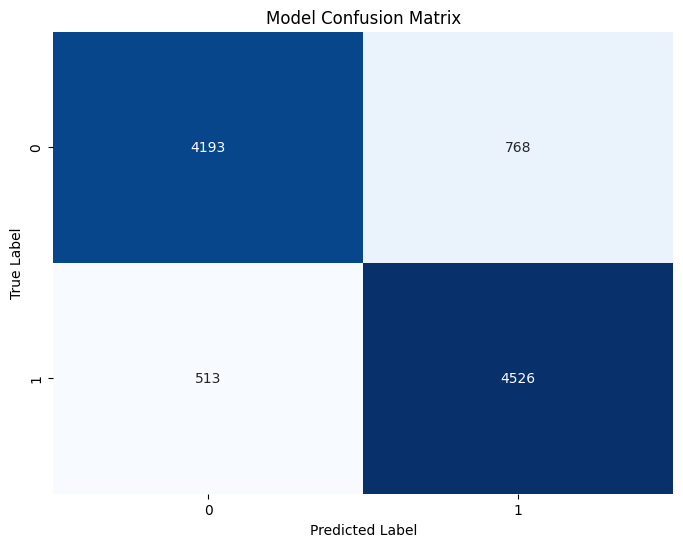

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred_probs = model.predict(X_test_tensor)

y_pred_classes = (y_pred_probs > 0.5).astype(int)

y_true = y_test_tensor

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Model Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()